##Multi Linear Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('/content/ToyotaCorolla - MLR.csv')

In [ ]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [ ]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [ ]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
df.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015
1435,6950,76,1,Petrol,110,0,1600,5,4,5,1114


In [ ]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

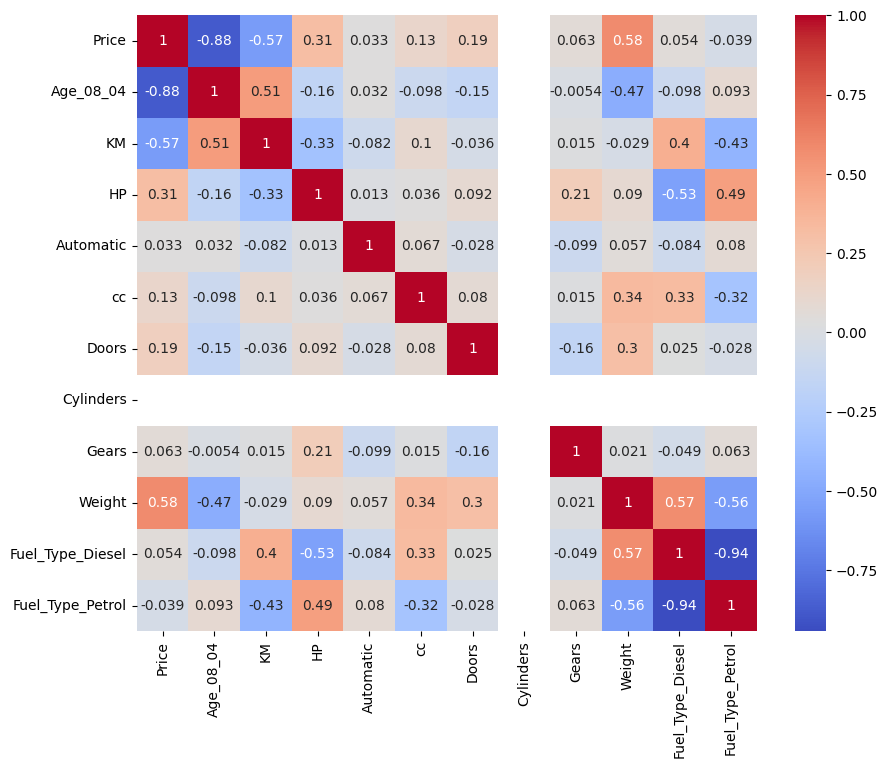

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


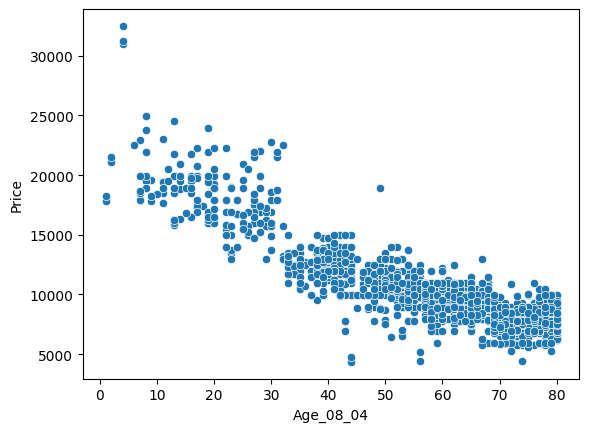

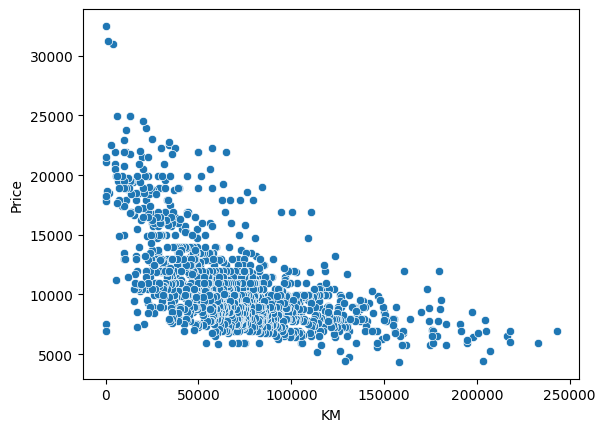

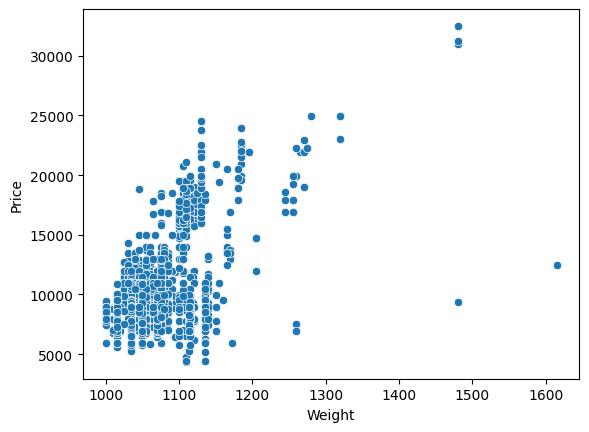

In [ ]:
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.show()

sns.scatterplot(x='KM', y='Price', data=df)
plt.show()

sns.scatterplot(x='Weight', y='Price', data=df)
plt.show()


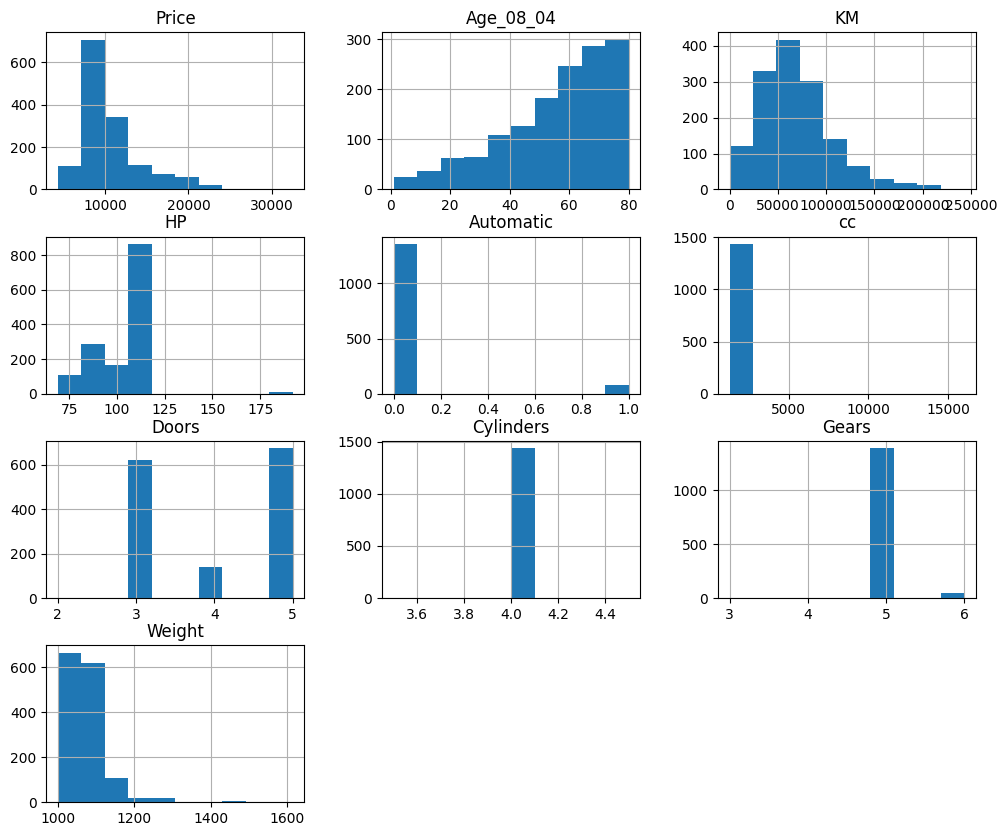

In [ ]:
df.hist(figsize=(12,10))
plt.show()

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))


R2 Score: 0.8348888040611082
RMSE: 1484.2654153296514


In [ ]:
# =========================================
# Correlation Analysis (Feature Importance)
# =========================================

corr = df.corr()['Price'].sort_values(ascending=False)
print("Correlation with Price:\n", corr)

# Identify weak features
weak_features = corr[abs(corr) < 0.1]
print("\nWeak Features:\n", weak_features)

Correlation with Price:
 Price               1.000000
Weight              0.581198
HP                  0.314990
Doors               0.185326
cc                  0.126389
Gears               0.063104
Fuel_Type_Diesel    0.054084
Automatic           0.033081
Fuel_Type_Petrol   -0.038516
KM                 -0.569960
Age_08_04          -0.876590
Cylinders                NaN
Name: Price, dtype: float64

Weak Features:
 Gears               0.063104
Fuel_Type_Diesel    0.054084
Automatic           0.033081
Fuel_Type_Petrol   -0.038516
Name: Price, dtype: float64


Interpretation:

- Features like Weight and HP have strong positive correlation with Price.
- Features like Age_08_04 and KM have negative correlation with Price.
- 'Automatic' has very low correlation, indicating it is a weak feature.

Conclusion:
Weak features do not significantly impact the model and can be removed.


##Coefficient Interpretation

In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})

print(coeff_df)

             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders -1.620037e-12
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03


Interpretation:

- A positive coefficient means that as the feature increases, the price increases.
- A negative coefficient means that as the feature increases, the price decreases.

Example:
- If 'Age_08_04' has a negative coefficient → older cars have lower price.
- If 'HP' has a positive coefficient → higher horsepower increases price.


In [ ]:
X2 = df[['Age_08_04','KM','HP','Weight','Automatic']]
y2 = df['Price']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y_pred2 = model2.predict(X2_test)

print("Model 2 R2:", r2_score(y2_test, y_pred2))


Model 2 R2: 0.8511893129923236


Model 2 uses selected features: Age, KM, HP, Weight, Automatic.

- These features were chosen based on correlation with Price.
- 'Automatic' may have low impact compared to other features.
- If R² does not improve significantly, it indicates weaker contribution.


In [ ]:
X3 = df[['Age_08_04','KM','HP','Weight']]
y3 = df['Price']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)

y_pred3 = model3.predict(X3_test)

print("Model 3 R2:", r2_score(y3_test, y_pred3))


Model 3 R2: 0.8506068681500583


Model 3 removes 'Automatic' feature.

- If Model 3 gives similar or better R² than Model 2,
  it indicates that 'Automatic' is a weak feature.
- Removing weak features simplifies the model and improves interpretability.


In [ ]:
print("Model 1 R2:", r2_score(y_test, y_pred1))
print("Model 1 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))


Model 1 R2: 0.8348888040611082
Model 1 RMSE: 1484.2654153296514


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train_s)

ridge_pred = ridge.predict(X_test_s)

print("Ridge R2:", r2_score(y_test_s, ridge_pred))


Ridge R2: 0.8350658145414687


In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_s, y_train_s)

lasso_pred = lasso.predict(X_test_s)

print("Lasso R2:", r2_score(y_test_s, lasso_pred))


Lasso R2: 0.8349119754675463


#Interview Questions:
1. What is Normalization & Standardization and how is it helpful?


##Normalization

####"Normalization is a scaling technique that transforms data into a fixed range,usually between 0 and 1, using Min-Max scaling.It ensures that features with larger values do not dominate machine learning models, especially distance-based algorithms."

#Standardization

####"Standardization is a scaling technique that transforms data to have mean 0 and standard deviation 1 using the Z-score formula.It is especially useful in regression and regularization methods like Ridge and Lasso."

2. What techniques can be used to address multicollinearity in multiple linear regression?

#Multicolinearity

###Techniques to Handle Multicollinearity

####1. It Remove correlated features
####2. It Use Variance Inflation Factor (VIF)
####3. Apply Ridge Regression
####4. Apply Lasso Regression
####5. Use PCA (Principal Component Analysis)

Conclusion:

- Multiple Linear Regression models were built and evaluated.
- Model performance was measured using R² and RMSE.
- Feature selection helped improve model efficiency.
- Weak features were identified and removed.
- Ridge and Lasso helped handle multicollinearity and overfitting.

Overall, the analysis provided insights into factors affecting car prices.
